**This notebook demonstrates how to create a GlacierMIP4 output file from the OGGM batch output files**.

First, we download OGGMs projections, e.g. like this:
wget -c -nc -r -np -nH --cut-dirs=7 -A "*.nc" https://cluster.klima.uni-bremen.de/~oggm/oggm-standard-projections/oggm_v16/2025.6/era5/per_glacier_spinup/CMIP6/2100/RGI01/

In [1]:
OGGM_data_folder = "oggm_data/2100/RGI01"

> We inspect one of OGGMs batch output files.

In [2]:
import xarray as xr
example_file_name = "run_hydro_era5_gcm_merged_MRI-ESM2-0_ssp119_bc_2000_2019_endyr2101_Batch_0_1000.nc"
ds = xr.load_dataset(OGGM_data_folder + "/" + example_file_name)
ds

<xarray.Dataset> Size: 47MB
Dimensions:                       (time: 102, rgi_id: 1000, month_2d: 12)
Coordinates:
  * time                          (time) float64 816B 2e+03 ... 2.101e+03
    hydro_year                    (time) int64 816B 2000 2001 2002 ... 2100 2101
    hydro_month                   (time) int64 816B 4 4 4 4 4 4 ... 4 4 4 4 4 4
    calendar_year                 (time) int64 816B 2000 2001 2002 ... 2100 2101
    calendar_month                (time) int64 816B 1 1 1 1 1 1 ... 1 1 1 1 1 1
  * rgi_id                        (rgi_id) <U14 56kB 'RGI60-01.00001' ... 'RG...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
Data variables: (12/29)
    volume                        (time, rgi_id) float32 408kB 6.713e+06 ... ...
    volume_bsl                    (time, rgi_id) float32 408kB 0.0 0.0 ... 0.0
    volume_bwl                    (time, rgi_id) float32 408kB 0.0 0.0 ... 0.0
    area                          (time, rgi_id) float32 408kB 3.553e+05 ... ...
    length                        (time, rgi_id) float32 408kB 828.0 ... 760.0
    calving                       (time, rgi_id) float32 408kB 0.0 0.0 ... 0.0
    ...                            ...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float32 5MB 6.153e...
    snow_bucket_monthly           (time, month_2d, rgi_id) float32 5MB 0.0 .....
    residual_mb_monthly           (time, month_2d, rgi_id) float32 5MB 0.0 .....
    water_level                   (rgi_id) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0
    glen_a                        (rgi_id) float32 4kB 8.025e-24 ... 8.025e-24
    fs                            (rgi_id) float32 4kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.3.dev30+gbba6e5f24
    calendar:       365-day no leap
    creation_date:  2025-12-17 21:27:43

> We find data variables per glacier over time (either annual or monthly) and flow calibration parameters per glacier.

> Let's create the regional GlacierMIP output files.
> We start with loading all the batch nc-files from one region and one simulation setup. 
> For this example, we assume that our OGGM data folder only contains these nc-files.

In [3]:
from pathlib import Path
files = sorted(Path(OGGM_data_folder).glob("*.nc"))

ds_mf = xr.open_mfdataset(
    files,
    combine="by_coords",
)

ds_mf

<xarray.Dataset> Size: 1GB
Dimensions:                       (time: 102, rgi_id: 27108, month_2d: 12)
Coordinates:
  * time                          (time) float64 816B 2e+03 ... 2.101e+03
    hydro_year                    (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    hydro_month                   (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    calendar_year                 (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    calendar_month                (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
  * rgi_id                        (rgi_id) <U14 2MB 'RGI60-01.00001' ... 'RGI...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B dask.array<chunksize=(12,), meta=np.ndarray>
Data variables: (12/29)
    volume                        (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    volume_bsl                    (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    volume_bwl                    (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    area                          (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    length                        (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    calving                       (time, rgi_id) float32 11MB dask.array<chunksize=(102, 1000), meta=np.ndarray>
    ...                            ...
    snowfall_on_glacier_monthly   (time, month_2d, rgi_id) float32 133MB dask.array<chunksize=(102, 12, 1000), meta=np.ndarray>
    snow_bucket_monthly           (time, month_2d, rgi_id) float32 133MB dask.array<chunksize=(102, 12, 1000), meta=np.ndarray>
    residual_mb_monthly           (time, month_2d, rgi_id) float32 133MB dask.array<chunksize=(102, 12, 1000), meta=np.ndarray>
    water_level                   (rgi_id) float32 108kB dask.array<chunksize=(1000,), meta=np.ndarray>
    glen_a                        (rgi_id) float32 108kB dask.array<chunksize=(1000,), meta=np.ndarray>
    fs                            (rgi_id) float32 108kB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.3.dev30+gbba6e5f24
    calendar:       365-day no leap
    creation_date:  2025-12-17 21:27:43

> For a regional aggregation we need to sum the values of individual glaciers per data variable.

In [4]:
regional_ds = ds_mf.sum(dim="rgi_id")
regional_ds

<xarray.Dataset> Size: 51kB
Dimensions:                       (time: 102, month_2d: 12)
Coordinates:
  * time                          (time) float64 816B 2e+03 ... 2.101e+03
    hydro_year                    (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    hydro_month                   (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    calendar_year                 (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    calendar_month                (time) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B dask.array<chunksize=(12,), meta=np.ndarray>
Data variables: (12/29)
    volume                        (time) float32 408B dask.array<chunksize=(102,), meta=np.ndarray>
    volume_bsl                    (time) float32 408B dask.array<chunksize=(102,), meta=np.ndarray>
    volume_bwl                    (time) float32 408B dask.array<chunksize=(102,), meta=np.ndarray>
    area                          (time) float32 408B dask.array<chunksize=(102,), meta=np.ndarray>
    length                        (time) float32 408B dask.array<chunksize=(102,), meta=np.ndarray>
    calving                       (time) float32 408B dask.array<chunksize=(102,), meta=np.ndarray>
    ...                            ...
    snowfall_on_glacier_monthly   (time, month_2d) float32 5kB dask.array<chunksize=(102, 12), meta=np.ndarray>
    snow_bucket_monthly           (time, month_2d) float32 5kB dask.array<chunksize=(102, 12), meta=np.ndarray>
    residual_mb_monthly           (time, month_2d) float32 5kB dask.array<chunksize=(102, 12), meta=np.ndarray>
    water_level                   float32 4B dask.array<chunksize=(), meta=np.ndarray>
    glen_a                        float32 4B dask.array<chunksize=(), meta=np.ndarray>
    fs                            float32 4B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    description:    OGGM model output
    oggm_version:   1.6.3.dev30+gbba6e5f24
    calendar:       365-day no leap
    creation_date:  2025-12-17 21:27:43

> Now we are in excellent conditions for converting to the GlacierMIP4 standardized output.
> First we create an empty GlacierMIP4 template file.

In [5]:
from src.create_template import create_glaciermip_dataset

start_date="2025-01-01"
end_date="2100-01-01"

glaciermip_ds = create_glaciermip_dataset(
    frequency="annual",
    start_date=start_date,
    end_date=end_date,
    epoch_date="1850-01-01",
    variable_yml="variable_definitions.yml",
)

glaciermip_ds

<xarray.Dataset> Size: 2kB
Dimensions:      (time: 76, nv: 2)
Coordinates:
  * time         (time) int32 304B 63918 64283 64648 65013 ... 90581 90946 91311
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 608B 63552 63918 63918 ... 90946 90946 91311
    area         (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    mass         (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    mass_bsl     (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    frontal_abl  (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

> Then we prepare OGGM's regional data.

In [6]:
# Let's add mass first in OGGM's data
GLACIERMIP_ICE_DENSITY = 900  # kg m-3
regional_ds["mass"] = regional_ds["volume"] * GLACIERMIP_ICE_DENSITY
regional_ds["mass_bsl"] = regional_ds["volume_bsl"] * GLACIERMIP_ICE_DENSITY

# Then we need to crop it to the same time window as the GlacierMIP output
start_year = 2025
end_year = 2100
regional_ds_sliced = regional_ds.sel(
    time=slice(start_year, end_year)
)

> Now we can insert OGGM's data into the GlacierMIP dataset. **Users have to make sure that the time (and time bounds) and units are matching in the original data!**


In [7]:
# We need a lookup table for the variable names (could be stored in external file)
glaciermip_names_to_oggm_names = {"area":"area", "frontal_abl":"calving", "mass":"mass", "mass_bsl":"mass_bsl"}

# Then we iterate over the data variables and simply paste the data
for var_name, da in glaciermip_ds.data_vars.items():
    # Exlude time bounds
    if "bounds" in var_name:
        continue
    
    oggm_name = glaciermip_names_to_oggm_names[var_name]
    glaciermip_ds[var_name].values = regional_ds_sliced[oggm_name].values

glaciermip_ds

<xarray.Dataset> Size: 2kB
Dimensions:      (time: 76, nv: 2)
Coordinates:
  * time         (time) int32 304B 63918 64283 64648 65013 ... 90581 90946 91311
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 608B 63552 63918 63918 ... 90946 90946 91311
    area         (time) float32 304B 8.402e+10 8.378e+10 ... 5.961e+10 6.249e+10
    mass         (time) float32 304B 1.597e+16 1.591e+16 ... 1.093e+16 1.095e+16
    mass_bsl     (time) float32 304B 7.83e+14 7.788e+14 ... 3.972e+14 3.953e+14
    frontal_abl  (time) float32 304B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

> That's it, we can store the dataset with the correct naming now.

In [8]:
import os

GLACIER_MODEL = "OGGM"
RGI_REGION = "01"
GCM = "MRI-ESM2-0"
SSP = "119"
FREQUENCY = "annual"

filename = GLACIER_MODEL + "_" + "rgi" + RGI_REGION + "_" + GCM + "_" + SSP + "_" + FREQUENCY + ".nc"

# toDo: What compression should be used?
os.makedirs("examples", exist_ok=True)
glaciermip_ds.to_netcdf("examples/" + filename)


> Let's quickly make the regional monthly file for the MB vars.

In [9]:
monthly_ds = create_glaciermip_dataset(
    frequency="monthly",
    start_date="2025-01-01",
    end_date="2101-01-01",
    epoch_date="1850-01-01",
    variable_yml="variable_definitions.yml",
)

monthly_ds

<xarray.Dataset> Size: 33kB
Dimensions:      (time: 913, nv: 2)
Coordinates:
  * time         (time) int32 4kB 63918 63949 63977 64008 ... 91615 91645 91676
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 7kB 63887 63918 63918 ... 91645 91645 91676
    acc          (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    melt         (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    refreeze     (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    runoff_glac  (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    precip       (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    temp         (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

> We can add the exisiting variables melt_on_glacier_monthly and snowfall_on_glacier_monthly directly from OGGM's files.

In [10]:
import numpy as np

glaciermip_names_to_oggm_names = {"acc":"snowfall_on_glacier_monthly", "melt":"melt_on_glacier_monthly"}

for var_name, da in monthly_ds.data_vars.items():
    # Exlude time bounds
    if "bounds" in var_name:
        continue

    if var_name not in glaciermip_names_to_oggm_names.keys():
        print(var_name + " not found")
        continue
    
    oggm_name = glaciermip_names_to_oggm_names[var_name]
    data = regional_ds_sliced[oggm_name].values.flatten().astype("float32")
    
    # We need to move the OGGM data by one to match the timebounds
    monthly_ds[var_name].values = np.insert(data, 0, np.nan)

monthly_ds

refreeze not found
runoff_glac not found
precip not found
temp not found


<xarray.Dataset> Size: 33kB
Dimensions:      (time: 913, nv: 2)
Coordinates:
  * time         (time) int32 4kB 63918 63949 63977 64008 ... 91615 91645 91676
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 7kB 63887 63918 63918 ... 91645 91645 91676
    acc          (time) float32 4kB nan 2.93e+13 ... 4.087e+13 2.127e+13
    melt         (time) float32 4kB nan 1.943e+11 ... 5.661e+11 8.247e+08
    refreeze     (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    runoff_glac  (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    precip       (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    temp         (time) float32 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

We can store the results like this:


In [11]:

FREQUENCY = "monthly"
filename_monthly = GLACIER_MODEL + "_" + "rgi" + RGI_REGION + "_" + GCM + "_" + SSP + "_" + FREQUENCY + ".nc"

monthly_ds.to_netcdf("examples/" + filename_monthly)

We can quickly visualize the result. Please notice that the first entry (December 2024) is not shown here, as it contains NA.

/home/johannes/mambaforge/envs/glaciermip-nc/lib/python3.12/site-packages/numpy/_core/shape_base.py:61: UserWarning: Warning: converting a masked element to nan.
  result = asanyarray(arys[0])


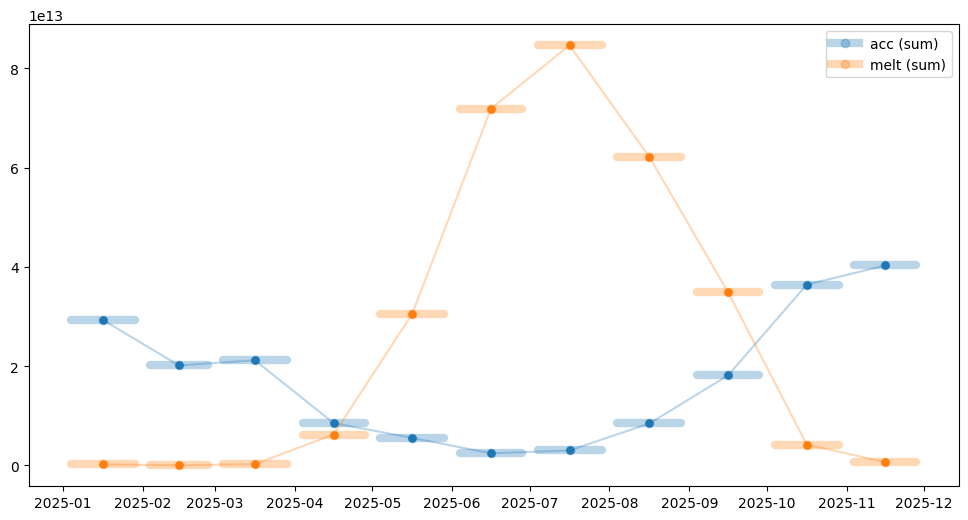

In [13]:
import iris
from src.visualize import plot_cf_cubes

cubes = iris.load(
    "examples/" + filename_monthly,
    ["acc", "melt"],
)

plot_cf_cubes(cubes, start_test=0, end=12)